# Current global Spotify reach and scene depth across the ten largest UK Functional Urban Areas

## tl;dr

This notebook asks two related questions about the ten largest UK Functional Urban Areas:

1. Which FUAs have the greatest current global Spotify monthly-listener reach
   across ten selected bands, relative to population?
2. Which results remain strong after reducing the influence of one
   exceptionally popular band?

Before population normalization, London, Manchester and Sheffield have the largest combined
reach. After dividing those same ten-band totals by FUA population,
Sheffield, Liverpool and Manchester lead. The largest selected band supplies
59% of Liverpool's reach and
57% of Sheffield's, compared with
32% in Manchester. After each FUA's largest
band is removed, the leading order becomes Sheffield, Manchester and Birmingham.

The primary result is the all-ten population-normalized ranking. Removing the
largest band is a separate scene-depth test.

> **Scope:** “Reach” means current global Spotify monthly listeners captured on
> 18 July 2026. Conclusions apply to the ten largest UK Functional Urban Areas, not every UK city, and
> do not measure historical importance or local listening.


## 01. Study question and design

The unit of analysis is an **OECD/EU Functional Urban Area (FUA)**: an urban
centre plus the surrounding places connected to it through commuting. The
study begins with the ten largest UK Functional Urban Areas, ranked by the OECD's 2021 population
observations, then assigns ten reviewed bands to each FUA. This produces a
balanced catalogue of 100 bands.

An act is assigned to the FUA where the band formed. Solo artists are outside
scope. Exactly ten bands per FUA prevents one area from receiving a larger
total merely because more acts were selected.

| Stage | Calculation | Question answered |
|---|---|---|
| Descriptive context | Sum all ten bands | Which selected FUA catalogues have the largest absolute current reach? |
| Primary: all ten | Sum all ten bands, then divide by FUA population | How large is selected current reach relative to area size? |
| Scene depth | Remove the largest band, sum the remaining nine, then divide by FUA population | Does the result survive without its dominant act? |

The raw total provides scale but structurally favours larger areas. The
all-ten population-normalized measure is the headline result. Largest-band
exclusion is a sensitivity test, not a replacement ranking.


## 02. Data and definitions

The analysis uses frozen Spotify snapshot **`20260718T204000Z`**, captured
on **18 July 2026**. Notebook execution is offline and cannot silently
refresh the values.

### Functional Urban Area universe

`reference/uk_fua_top20_2021.csv` freezes the 2021 population universe and the official FUA
codes used here.

- [OECD definition of cities and Functional Urban Areas](https://www.oecd.org/en/data/datasets/oecd-definition-of-cities-and-functional-urban-areas.html)
- [OECD Data Explorer: Population by age and sex — Cities and FUAs](https://data-explorer.oecd.org/vis?df%5Bag%5D=OECD.CFE.EDS&df%5Bds%5D=dsDisseminateFinalDMZ&df%5Bid%5D=DSD_FUA_DEMO%40DF_AGE_SEX&lc=en)

The EU–OECD definition uses population density to identify urban centres and
commuting flows to add economically connected surrounding areas. That makes
the denominator consistent across England, Scotland, Wales and Northern
Ireland.

### Band catalogue and reach metric

`data/processed/fua_top10_band_metrics_20260718T204000Z.csv` contains the 100 reviewed band–FUA assignments,
Spotify identities, FUA population fields, and frozen monthly listeners. Every
FUA contributes exactly ten bands. Monthly listeners are current global
platform reach; they are not listeners living in the FUA.

### Saved result

`data/processed/fua_top10_rankings_20260718T204000Z.csv` stores the raw, population-normalized, and largest-band-
excluded rankings. The notebook recomputes them from band-level data and checks
them against the saved file before showing findings.


## 03. Calculation and assumptions

For FUA \(c\), let \(L_{ic}\) be band \(i\)'s monthly listeners and
\(P_c\) its 2021 OECD FUA population:

- **Raw total:** \(\sum_{i=1}^{10} L_{ic}\)
- **Population-normalized all ten:** \(\sum_{i=1}^{10} L_{ic} / P_c\)
- **Largest excluded:** \((\sum L_{ic} - \max L_{ic}) / P_c\)

### Key assumptions

- The population-selected universe supports conclusions about the ten largest UK Functional Urban Areas,
  not every UK city.
- The balanced catalogue is manually curated, genre-influenced, and not a
  random sample of bands.
- Formation place is the working definition of origin. Some assignments within
  a wider FUA require editorial judgement.
- Spotify monthly listeners measure current global reach, not cultural impact,
  record sales, or local listening.
- FUA population is a size denominator, not an estimate of local audience.
- Largest-band exclusion reduces sensitivity to one extreme but cannot remove
  catalogue-selection bias.

The following cells validate the 100-by-10 design, FUA
mapping, Spotify identities, capture consistency, population values, and saved
calculations.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from pandas.testing import assert_frame_equal
from IPython.display import display


def find_project_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "reference" / "uk_fua_top20_2021.csv").exists():
            return candidate
    raise FileNotFoundError(
        "Run this notebook from inside the uk-music-cities repository"
    )


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


def display_path(path: Path) -> Path:
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


from python_uk_bands.fua import validate_top_fua_universe
from python_uk_bands.scene_depth import (
    build_primary_scene_depth_rankings,
    validate_scene_depth_dataset,
)
from python_uk_bands.scene_depth_visuals import (
    plot_raw_city_totals,
    plot_raw_normalized_scene_depth_rank_comparison,
    plot_ten_band_city_stack,
    plot_ten_band_population_normalized_total,
)
from python_uk_bands.visuals import apply_chart_style

apply_chart_style()


In [2]:
SNAPSHOT_ID = "20260718T204000Z"
EXPECTED_CITIES = 10
BANDS_PER_CITY = 10
METRICS_PATH = PROJECT_ROOT / 'data/processed/fua_top10_band_metrics_20260718T204000Z.csv'
SAVED_RANKINGS_PATH = PROJECT_ROOT / 'data/processed/fua_top10_rankings_20260718T204000Z.csv'
FUA_UNIVERSE_PATH = PROJECT_ROOT / 'reference/uk_fua_top20_2021.csv'
CHART_OUTPUT_DIR = PROJECT_ROOT / 'artifacts/charts'

band_data = pd.read_csv(METRICS_PATH, keep_default_na=False)
saved_rankings = pd.read_csv(SAVED_RANKINGS_PATH)
fua_universe = pd.read_csv(FUA_UNIVERSE_PATH, keep_default_na=False).head(
    EXPECTED_CITIES
)

validate_scene_depth_dataset(
    band_data,
    expected_cities=EXPECTED_CITIES,
    bands_per_city=BANDS_PER_CITY,
)
validate_top_fua_universe(
    fua_universe,
    expected_rows=EXPECTED_CITIES,
    year=2021,
)
assert len(band_data) == EXPECTED_CITIES * BANDS_PER_CITY
assert band_data["band"].nunique() == len(band_data)
assert band_data["spotify_id"].nunique() == len(band_data)
assert band_data["catalogue_review_ready"].astype(bool).all()
assert band_data["monthly_listeners"].ge(0).all()
assert band_data["stats_extracted_at_utc"].nunique() == 1

observed_population = (
    band_data[
        [
            "uk_population_rank",
            "fua_code",
            "city",
            "population_year",
            "population",
        ]
    ]
    .drop_duplicates()
    .sort_values("uk_population_rank")
    .reset_index(drop=True)
)
expected_population = (
    fua_universe[
        [
            "uk_population_rank",
            "fua_code",
            "study_city_label",
            "population_year",
            "population",
        ]
    ]
    .rename(columns={"study_city_label": "city"})
    .reset_index(drop=True)
)
assert_frame_equal(
    observed_population,
    expected_population,
    check_dtype=False,
)

quality_summary = pd.DataFrame(
    {
        "Check": [
            "Bands",
            "FUAs",
            "Bands per FUA",
            "Unique Spotify identities",
            "Reviewed catalogue rows",
            "Low-confidence origin rows",
        ],
        "Value": [
            len(band_data),
            band_data["city"].nunique(),
            int(band_data.groupby("city").size().min()),
            band_data["spotify_id"].nunique(),
            int(band_data["catalogue_review_ready"].astype(bool).sum()),
            int(band_data["origin_confidence"].eq("low").sum()),
        ],
    }
)
display(quality_summary)


,Check,Value
0,Bands,100
1,FUAs,10
2,Bands per FUA,10
3,Unique Spotify identities,100
4,Reviewed catalogue rows,100
5,Low-confidence origin rows,2


In [3]:
rankings = build_primary_scene_depth_rankings(
    band_data,
    metric="monthly_listeners",
    expected_cities=EXPECTED_CITIES,
    bands_per_city=BANDS_PER_CITY,
)
primary_result_columns = ['city', 'population', 'input_bands', 'highest_excluded_bands', 'all_ten_value', 'all_ten_ratio', 'top_excluded_value', 'top_excluded_ratio', 'top_band_concentration', 'metric', 'raw_total_rank', 'all_ten_rank', 'top_excluded_rank']
assert_frame_equal(
    rankings[primary_result_columns].sort_values("city").reset_index(drop=True),
    saved_rankings[primary_result_columns]
    .sort_values("city")
    .reset_index(drop=True),
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)


## 04. From bands to FUA impact

### 04.01 Band contributions to FUA totals

Each equal-length bar contains all ten selected bands for one FUA and totals
100%. Segment 1 is that area's largest current act, segment 2 its second
largest, and so on. The key names every band. This isolates composition and
concentration; the next chart restores absolute totals.


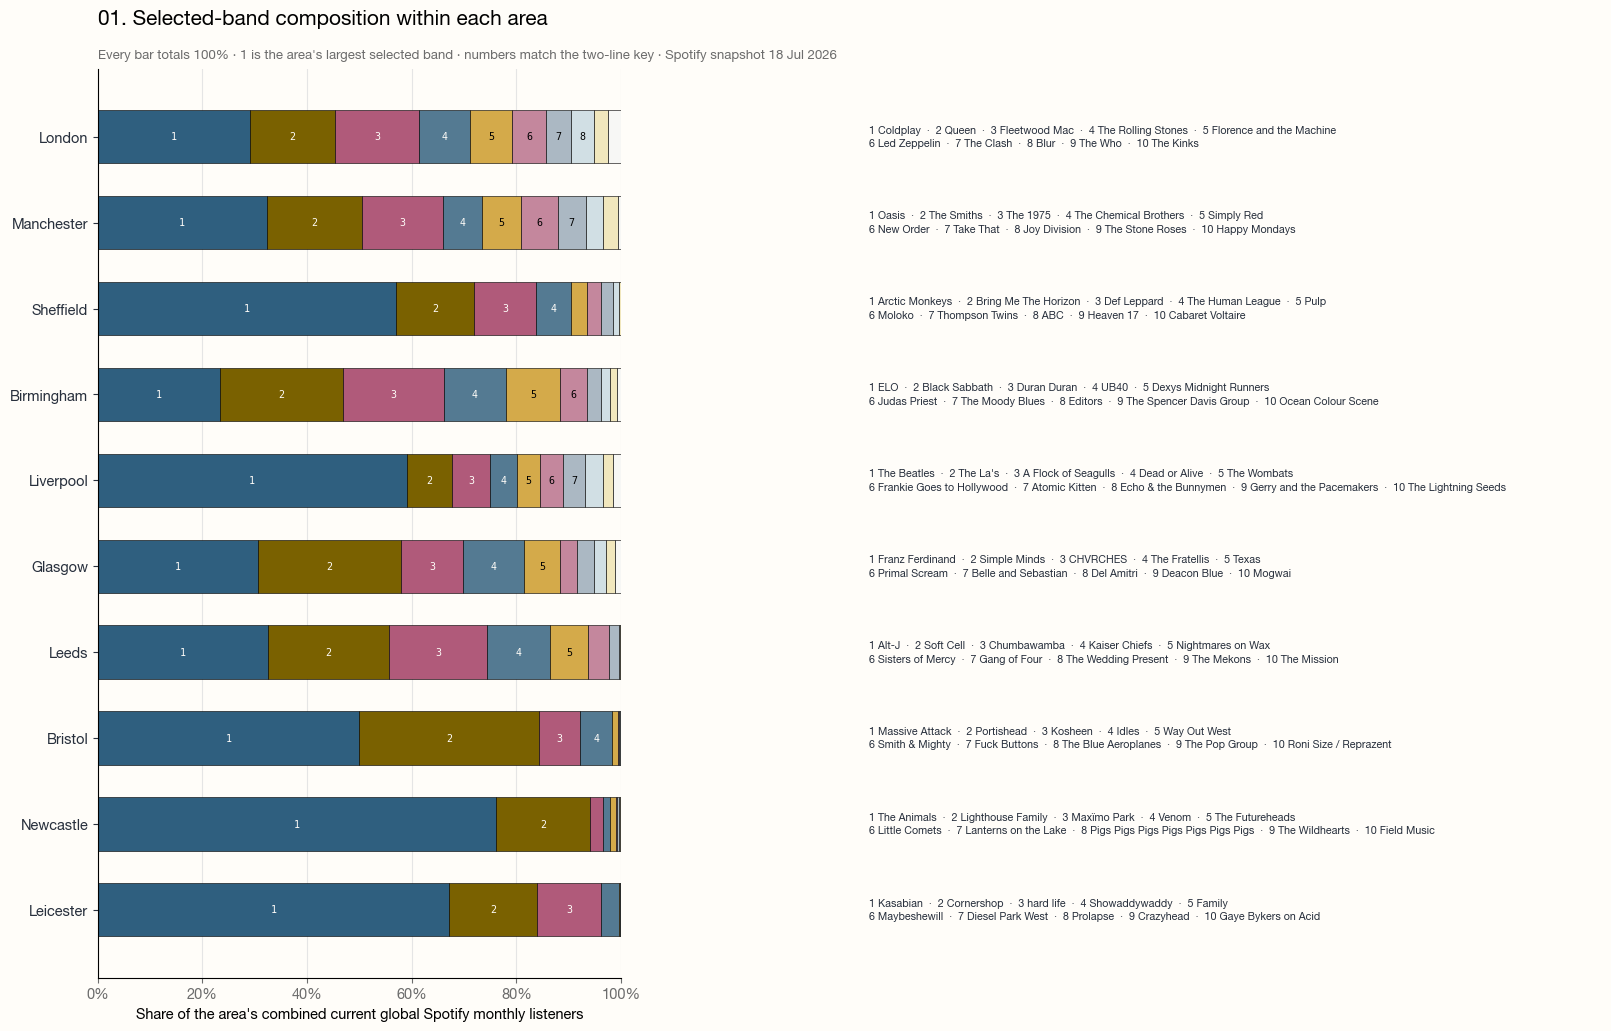

PosixPath('artifacts/charts/chart_01_fua_band_share_stack.png')

In [4]:
figure_01_path = plot_ten_band_city_stack(
    band_data,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=1,
    filename="chart_01_fua_band_share_stack.png",
)
display_path(figure_01_path)


### 04.02 Most impactful FUAs before population normalization

With the ten selected bands simply added together, London, Manchester and Sheffield have the
largest absolute current reach. This is catalogue scale, not the answer to
which area “punches above its weight.”


In [5]:
raw_fua_table = rankings[
    [
        "raw_total_rank",
        "city",
        "all_ten_value",
        "population",
        "all_ten_rank",
    ]
].sort_values("raw_total_rank").rename(
    columns={
        "raw_total_rank": "Raw rank",
        "city": "FUA",
        "all_ten_value": "Combined current global monthly listeners",
        "population": "2021 OECD FUA population",
        "all_ten_rank": "Population-normalized rank",
    }
)
display(raw_fua_table)


,Raw rank,FUA,Combined current global monthly listeners,2021 OECD FUA population,Population-normalized rank
3,1,London,316850941,12274097,4
2,2,Manchester,122954613,3432092,3
0,3,Sheffield,91712251,1168389,1
4,4,Birmingham,78260225,3135994,5
1,5,Liverpool,64261555,1540817,2
5,6,Glasgow,35258199,1831890,6
8,7,Leeds,24955874,2969034,9
6,8,Bristol,17389817,979556,7
7,9,Newcastle,16201200,1173303,8
9,10,Leicester,5439076,922812,10


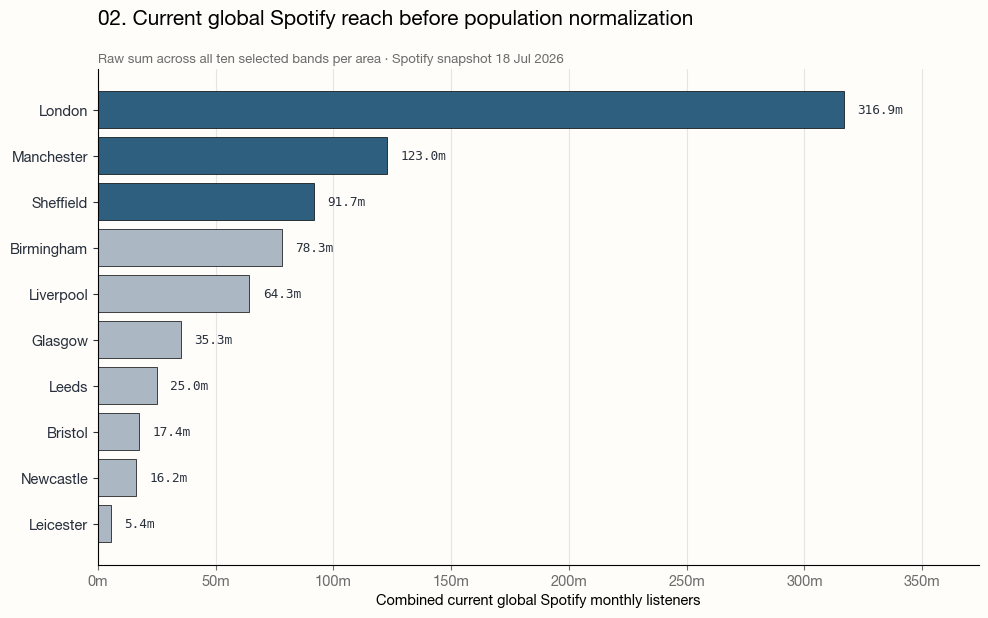

PosixPath('artifacts/charts/chart_02_raw_fua_totals.png')

In [6]:
figure_02_path = plot_raw_city_totals(
    rankings,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=2,
    filename="chart_02_raw_fua_totals.png",
)
display_path(figure_02_path)


### 04.03 Primary result: FUA-population-normalized reach

After the same all-ten totals are divided by 2021 OECD FUA population,
Sheffield, Liverpool and Manchester lead. No band has been removed from this primary ranking.


In [7]:
all_ten_table = rankings[
    [
        "all_ten_rank",
        "city",
        "all_ten_ratio",
        "highest_excluded_bands",
        "top_band_concentration",
    ]
].sort_values("all_ten_rank").rename(
    columns={
        "all_ten_rank": "Rank",
        "city": "FUA",
        "all_ten_ratio": "Current global ten-band reach / FUA population",
        "highest_excluded_bands": "Largest selected band",
        "top_band_concentration": "Largest-band share",
    }
)
display(all_ten_table)


,Rank,FUA,Current global ten-band reach / FUA population,Largest selected band,Largest-band share
0,1,Sheffield,78.494620,Arctic Monkeys,0.570282
1,2,Liverpool,41.706157,The Beatles,0.590207
2,3,Manchester,35.824976,Oasis,0.322692
3,4,London,25.814603,Coldplay,0.290465
4,5,Birmingham,24.955477,ELO,0.234227
5,6,Glasgow,19.246897,Franz Ferdinand,0.306531
6,7,Bristol,17.752754,Massive Attack,0.499886
7,8,Newcastle,13.808198,The Animals,0.760705
8,9,Leeds,8.405385,Alt-J,0.325011
9,10,Leicester,5.894024,Kasabian,0.670905


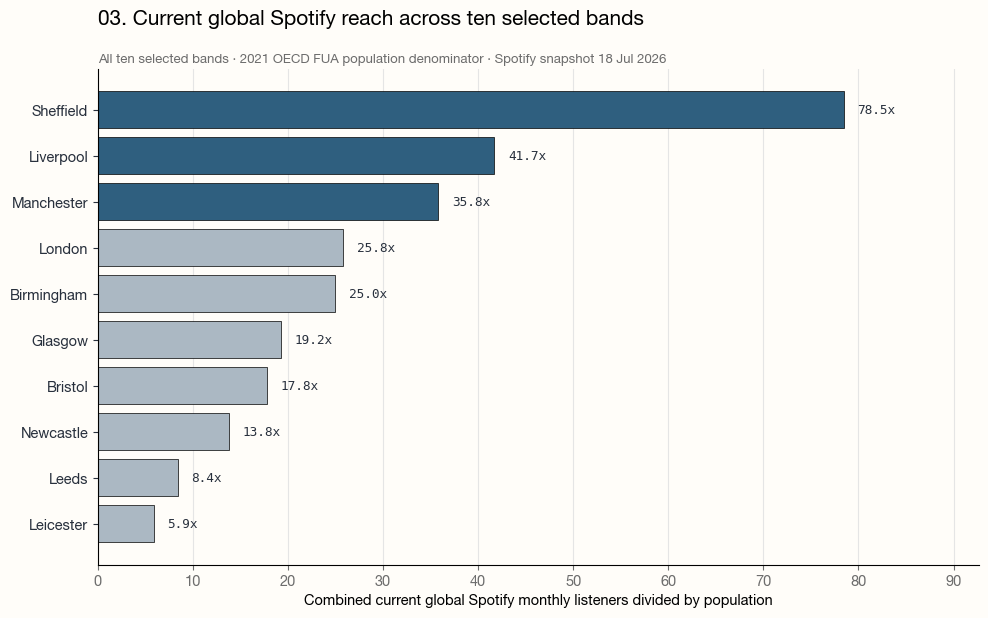

PosixPath('artifacts/charts/chart_03_fua_population_normalized_total.png')

In [8]:
figure_03_path = plot_ten_band_population_normalized_total(
    rankings,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=3,
    filename="chart_03_fua_population_normalized_total.png",
    denominator_description="2021 OECD FUA population denominator",
)
display_path(figure_03_path)


## 05. Why test scene depth?

The 100% chart shows whether one act dominates a selected FUA catalogue. The
Beatles supply 59.0% of Liverpool's total;
Arctic Monkeys supply 57.0% of Sheffield's;
Manchester's largest selected band supplies
32.3%.

Those bands remain fully included in the primary result. The additional test
asks whether an FUA still looks strong after its single largest act is removed.


## 06. Scene-depth test: remove the largest band

After each FUA's largest selected band is removed,
Sheffield, Manchester and Birmingham lead. Manchester moves from rank
3 to 2;
Sheffield moves from 1 to
1; Liverpool moves from
2 to 5.

This is the notebook's only alternative ranking. It retains nine bands per FUA.


In [9]:
largest_excluded_table = rankings[
    [
        "top_excluded_rank",
        "city",
        "top_excluded_ratio",
        "highest_excluded_bands",
        "all_ten_rank",
    ]
].copy()
largest_excluded_table["rank_change"] = (
    largest_excluded_table["all_ten_rank"]
    - largest_excluded_table["top_excluded_rank"]
)
display(
    largest_excluded_table.sort_values("top_excluded_rank").rename(
        columns={
            "top_excluded_rank": "Rank",
            "city": "FUA",
            "top_excluded_ratio": "Current global other-nine reach / FUA population",
            "highest_excluded_bands": "Band removed",
            "all_ten_rank": "All-ten rank",
            "rank_change": "Places gained",
        }
    )
)


,Rank,FUA,Current global other-nine reach / FUA population,Band removed,All-ten rank,Places gained
0,1,Sheffield,33.730531,Arctic Monkeys,1,0
2,2,Manchester,24.264542,Oasis,3,1
4,3,Birmingham,19.110228,ELO,5,2
3,4,London,18.316365,Coldplay,4,0
1,5,Liverpool,17.090880,The Beatles,2,-3
5,6,Glasgow,13.347125,Franz Ferdinand,6,0
6,7,Bristol,8.878396,Massive Attack,7,0
8,8,Leeds,5.673541,Alt-J,9,1
7,9,Newcastle,3.304236,The Animals,8,-1
9,10,Leicester,1.939696,Kasabian,10,0


## 07. Raw, normalized and scene-depth rankings

The final chart puts the three views on one rank scale: absolute catalogue
impact, the FUA-population-normalized primary result, and the largest-band-
excluded sensitivity.


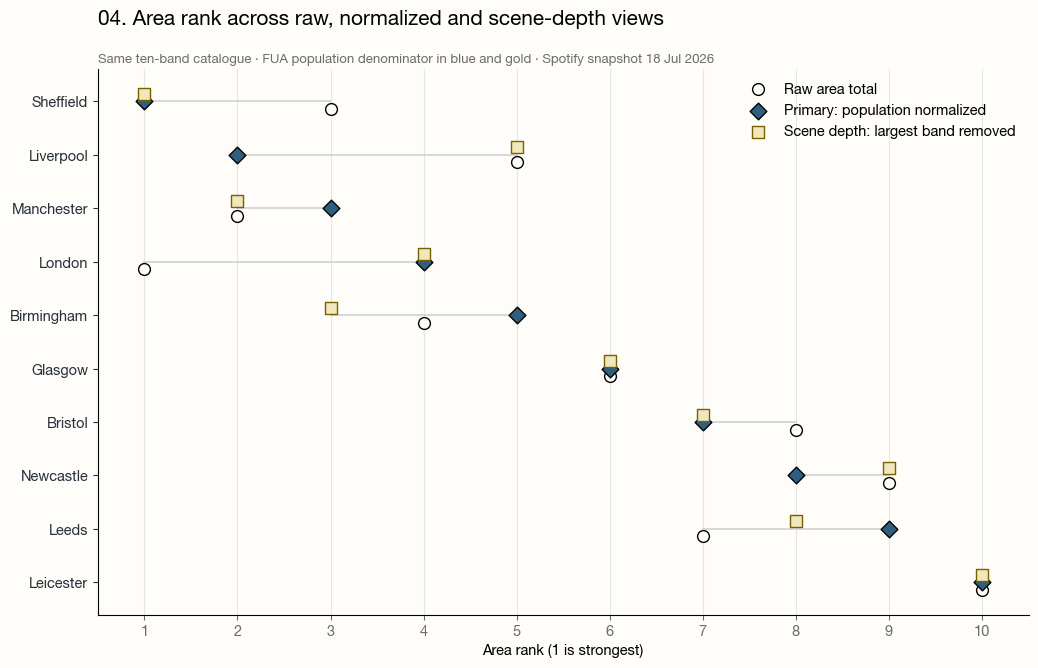

PosixPath('artifacts/charts/chart_04_raw_normalized_scene_depth_fua_ranks.png')

In [10]:
figure_04_path = plot_raw_normalized_scene_depth_rank_comparison(
    rankings,
    snapshot_date="18 Jul 2026",
    output_dir=CHART_OUTPUT_DIR,
    number=4,
    filename="chart_04_raw_normalized_scene_depth_fua_ranks.png",
)
display_path(figure_04_path)


## 08. Findings

Within the ten largest UK Functional Urban Areas and this balanced 100-band catalogue:

- **Raw all-ten totals:** London, Manchester and Sheffield lead before population
  normalization.
- **Primary all-ten result:** Sheffield, Liverpool and Manchester have the greatest selected
  current reach relative to FUA population.

- **Largest band excluded:** Sheffield, Manchester and Birmingham lead the scene-depth
  sensitivity.
- **Concentration:** Liverpool and Sheffield depend more heavily on their
  largest selected act than Manchester does.

The headline remains the all-ten FUA-population-normalized ranking. The
scene-depth test answers a narrower robustness question.


## 09. Limitations

- Conclusions apply to the ten largest UK Functional Urban Areas, not every UK city.
- The catalogue is manually curated, excludes solo artists, reflects the
  project's genre lane, and is not a random sample.
- 2 assignments are marked low confidence;
  2 carry the `review_required` alignment label.
- A formation place can sit in the urban centre or wider commuting zone.
  Mapping a music scene onto an FUA therefore involves editorial judgement.
- Monthly listeners are volatile global Spotify reach observed once. They are
  not historical impact or local listening.
- Dividing global reach by FUA population is a size normalization, not a local
  listening rate.
- Largest-band exclusion cannot remove catalogue-selection bias.

The supported conclusion is narrow: the notebook ranks the selected catalogue
relative to a consistent FUA denominator and then shows how much that order
depends on each area's largest selected band.

Charts are saved under `artifacts/charts`.


## Appendix A. Why the geography changed

Earlier versions used a mixed set of census built-up areas inherited from the
original shortlist. That was workable for exploration, but it was not a
population-selected universe and did not provide one harmonized geography
across all four UK nations.

The FUA version starts from the official OECD population table. This also
changes the top-ten panel: Bradford is not a separate entry in the OECD FUA
universe, Nottingham ranks eleventh, and Newcastle and Leicester enter the ten
largest FUAs. The previous built-up-area notebook remains preserved in the
project snapshots rather than being silently rewritten.

Source references:

- [OECD FUA definition and boundary resources](https://www.oecd.org/en/data/datasets/oecd-definition-of-cities-and-functional-urban-areas.html)
- [OECD population dataset used for the frozen 2021 universe](https://data-explorer.oecd.org/vis?df%5Bag%5D=OECD.CFE.EDS&df%5Bds%5D=dsDisseminateFinalDMZ&df%5Bid%5D=DSD_FUA_DEMO%40DF_AGE_SEX&lc=en)


## Appendix B. Useful dead ends

Google Trends was rejected as the common popularity measure because sampled,
request-normalized results were unstable across batches. MusicBrainz remains
useful for discovery and identity resolution but cannot decide editorial
questions such as formation place or what counts as a band. The earlier
five-band and built-up-area analyses remain part of the audit trail, not part
of this estimator.
